# El Perceptrón

Si la Neurona de McCulloch-Pitts fue la base, el **Perceptrón** de Frank Rosenblatt fue el primer modelo que le dio la capacidad de aprender.

Publicado en 1957 por el Laboratorio de Aeronáutica de Cornell, el Perceptrón no fue solo un algoritmo, sino una máquina física (el Mark I Perceptron) diseñada para el reconocimiento de imágenes.

### 🌟 La Gran Diferencia
La Neurona MP requería que un humano diseñara a mano los umbrales; mientras que el **Perceptrón** es capaz de encontrar los parámetros correctos por sí mismo mediante un proceso iterativo llamado **Entrenamiento**.

## 1. Arquitectura Matemática

El Perceptrón introduce cambios fundamentales en la ecuación de la neurona:

1.  **Entradas ($x$):** Ya no son solo binarias (0,1). Ahora pueden ser números reales.
2.  **Pesos ($w$):** Cada conexión tiene una importancia variable. Un peso positivo excita la neurona; un peso negativo la inhibe.
3.  **Sesgo ($b$ o Bias):** Reemplaza al umbral fijo. Es un valor extra que siempre entra con valor 1 y permite desplazar la función de activación.
4.  **Suma Ponderada ($z$):**
    $$z = w_1x_1 + w_2x_2 + ... + w_nx_n + b = \sum (w_i \cdot x_i) + b$$

### Función de Activación
El Perceptrón original usaba una función escalón simple para clasificar:

$$y_{pred} = \begin{cases} 1 & \text{si } z \ge 0 \\ 0 & \text{si } z < 0 \end{cases}$$


## 2. El Algoritmo del Perceptrón

El secreto es un mecanismo de corrección de errores. El Perceptrón mira un ejemplo, hace una predicción, y si se equivoca, ajusta sus pesos ligeramente para hacerlo mejor la próxima vez.

**La Regla de Actualización de Pesos:**
$$w_{nuevo} = w_{viejo} + \Delta w$$

Donde el cambio ($\Delta w$) se calcula así:
$$\Delta w = \eta \cdot (y_{real} - y_{pred}) \cdot x_i$$

* **$\eta$ (Tasa de Aprendizaje / Learning Rate):** Un número pequeño (0.1) que controla qué tan drástico es el cambio. Si es muy grande, el modelo "salta" y no aprende; si es muy pequeño, tarda una eternidad.
* **$(y_{real} - y_{pred})$:** El Error.
    * Si predice bien (1 y era 1), el error es 0 $\rightarrow$ No hay cambios.
    * Si predice mal (0 y era 1), el error es 1 $\rightarrow$ Aumenta los pesos.
    * Si predice mal (1 y era 0), el error es -1 $\rightarrow$ Disminuye los pesos.

## 3. Diferencias entre MP y Perceptrón

| Característica | Neurona MP (1943) | Perceptrón (1957) |
| :--- | :--- | :--- |
| **Entradas ($x$)** | Solo Binarias (0, 1) | Números Reales (cualquier valor) |
| **Pesos ($w$)** | Fijos (todos valen 1) | **Variables (se aprenden)** |
| **Umbral** | Fijo (manual) | **Sesgo ($b$) (se aprende)** |
| **Aprendizaje** | Diseño manual | **Automático (algoritmo)** |

## 4. Ejercicio Práctico Perceptrón

A continuación, se desarrolla un nuevo ejercicio de clasificación con el Perceptrón, basándose en la implementación anterior. Se han alterado ciertos parámetros y variables para explicar con mayor claridad su funcionamiento e impacto en el aprendizaje:
- **Dataset** : En lugar de la resolución 28x28 de `mnist_784`, utilizaremos `load_digits` de sklearn, un dataset similar pero con imágenes de 8x8 píxeles. Esto facilita la visualización y hace que el entrenamiento sea muy rápido para una prueba de concepto.
- **test_size** : Ajustado a `0.2` (20%) para la división de prueba en lugar del 10% usado en el ejemplo anterior, lo que brinda una cantidad mayor de datos no vistos por el modelo para una validación más robusta.
- **eta0 (tasa de aprendizaje)** : Modificada a `0.05` desde su valor por defecto. Una tasa de aprendizaje ligeramente reducida ayuda a que el algoritmo ajuste los pesos más progresivamente, evitando grandes oscilaciones si los datos no son perfectamente separables.

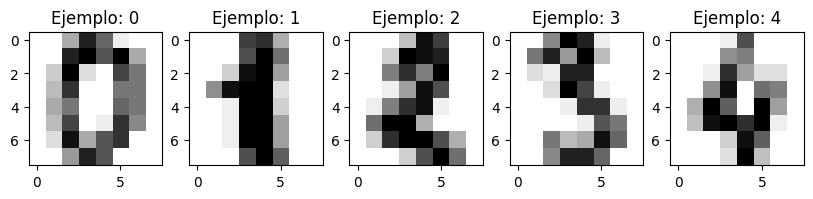

In [1]:
# Se usan las mismas librerías pero cambiamos el dataset por load_digits
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Variable alterada: usamos 'digitos' (8x8 píxeles) en lugar de 'mnist'
digitos = load_digits()

plt.figure(figsize=(10, 3))
for index, digit in zip(range(1, 6), digitos.data[:5]):
    plt.subplot(1, 5, index)
    plt.imshow(np.reshape(digit, (8,8)), cmap=plt.cm.gray_r)
    plt.title('Ejemplo: ' + str(digitos.target[index-1]))
plt.show()

In [2]:
# Modificación de parámetros de división
# test_size=0.2 (20% para test y 80% para train) en vez del 0.1 previo.
# random_state=42 agregado para reproducibilidad de los resultados exactos.
X_train, X_test, y_train, y_test = train_test_split(digitos.data, digitos.target, test_size=0.2, random_state=42)

# Modificación del Perceptrón:
# eta0 = 0.05: se reduce la tasa de aprendizaje para tener pasos de ajuste más finos.
# max_iter = 500: iteraciones máximas reducidas al ser un problema más simple.
clf = Perceptron(max_iter=500, eta0=0.05, random_state=40, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
score = f1_score(y_test, y_pred, average="weighted")
print("F1 Score (Puntuación general):", score)

F1 Score (Puntuación general): 0.9617628316771218


<Figure size 800x600 with 0 Axes>

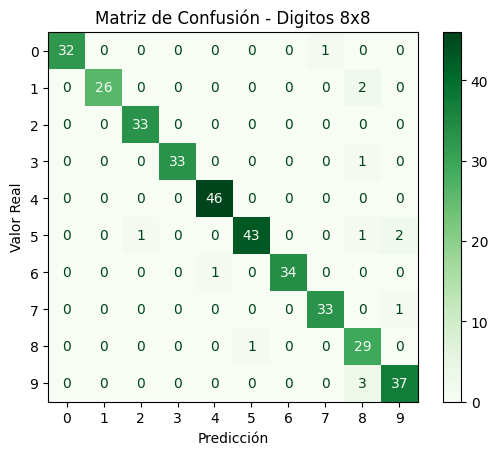

In [3]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
# Alterado el mapa de colores a Greens para diferenciarlo del ejemplo base
disp.plot(cmap=plt.cm.Greens)

plt.title("Matriz de Confusión - Digitos 8x8")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()